In [13]:
# Librerias
from google.colab import drive  # subir data
import pandas as pd             # data frames
import numpy as np              # vectores

In [14]:
drive.mount('/content/drive')

ruta_balance='/content/drive/MyDrive/Portafolio/Prueba_1/data/Balance.xlsx'
ruta_factor_riesgo='/content/drive/MyDrive/Portafolio/Prueba_1/data/Factores de Riesgo.xlsx'

balance = pd.read_excel(ruta_balance)
factor_riesgo=pd.read_excel(ruta_factor_riesgo)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Balance proyectado

In [15]:
import pandas as pd

RUTA_SIM = '/content/drive/MyDrive/Portafolio/Prueba_1/data/simulacion_VAR_bootstrap/escenarios_VAR_bootstrap_long.parquet'
esc = pd.read_parquet(RUTA_SIM)

print("Columnas:")
print(esc.columns.tolist())
print("\nPrimeras filas:")
print(esc.head(10))
print("\nShape:", esc.shape)

Columnas:
['escenario', 'horizonte', 'fecha_futura', 'diff_DTF', 'DTF', 'diff_IBR', 'IBR', 'diff_IPC', 'IPC', 'diff_Cuvr', 'Cuvr', 'diff_Auvr', 'Auvr', 'diff_TA_Jur', 'TA_Jur']

Primeras filas:
   escenario  horizonte fecha_futura  diff_DTF       DTF  diff_IBR       IBR  \
0          1          1   2020-05-31 -0.003159  0.041841 -0.001167  0.032782   
1          1          2   2020-06-30 -0.003190  0.038652 -0.001353  0.031429   
2          1          3   2020-07-31 -0.002822  0.035830 -0.002303  0.029127   
3          1          4   2020-08-31 -0.000753  0.035077 -0.001813  0.027314   
4          1          5   2020-09-30 -0.001087  0.033989 -0.000516  0.026798   
5          1          6   2020-10-31 -0.000046  0.033944  0.000035  0.026833   
6          1          7   2020-11-30  0.000048  0.033991  0.000950  0.027783   
7          1          8   2020-12-31 -0.002944  0.031048 -0.004858  0.022925   
8          1          9   2021-01-31 -0.003082  0.027965 -0.002325  0.020600   
9     

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BALANCE - columnas
['Código', 'PuntosAdicionales', 'Signo', 'TasaBase', 'PeriodoInteres', 'FrecuenciaInteres', 'Fecha Inicio', 'Fecha Vencimiento', 'Cartera', 'PlanAmortizacion', 'SaldoCapital', 'naturaleza', 'Tasa']

FACTORES - columnas
['Fecha', 'TA_Jur', 'DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr']

ESCENARIOS - columnas
['escenario', 'horizonte', 'fecha_futura', 'diff_DTF', 'DTF', 'diff_IBR', 'IBR', 'diff_IPC', 'IPC', 'diff_Cuvr', 'Cuvr', 'diff_Auvr', 'Auvr', 'diff_TA_Jur', 'TA_Jur']
Horizontes únicos por escenario: {12: 1000}
Número de filas por escenario: {12: 1000}

NII BASE
NII base total: -12,946,667.57
Escenarios detectados: 1000
Valorados    1 / 1000 escenarios
Valorados  100 / 1000 escenarios
Valorados  200 / 1000 escenarios
Valorados  300 / 1000 escenarios
Valorados  400 / 1000 escenarios
Valorados  500 / 1000 escenarios
Valorados  600 / 1000 escenarios


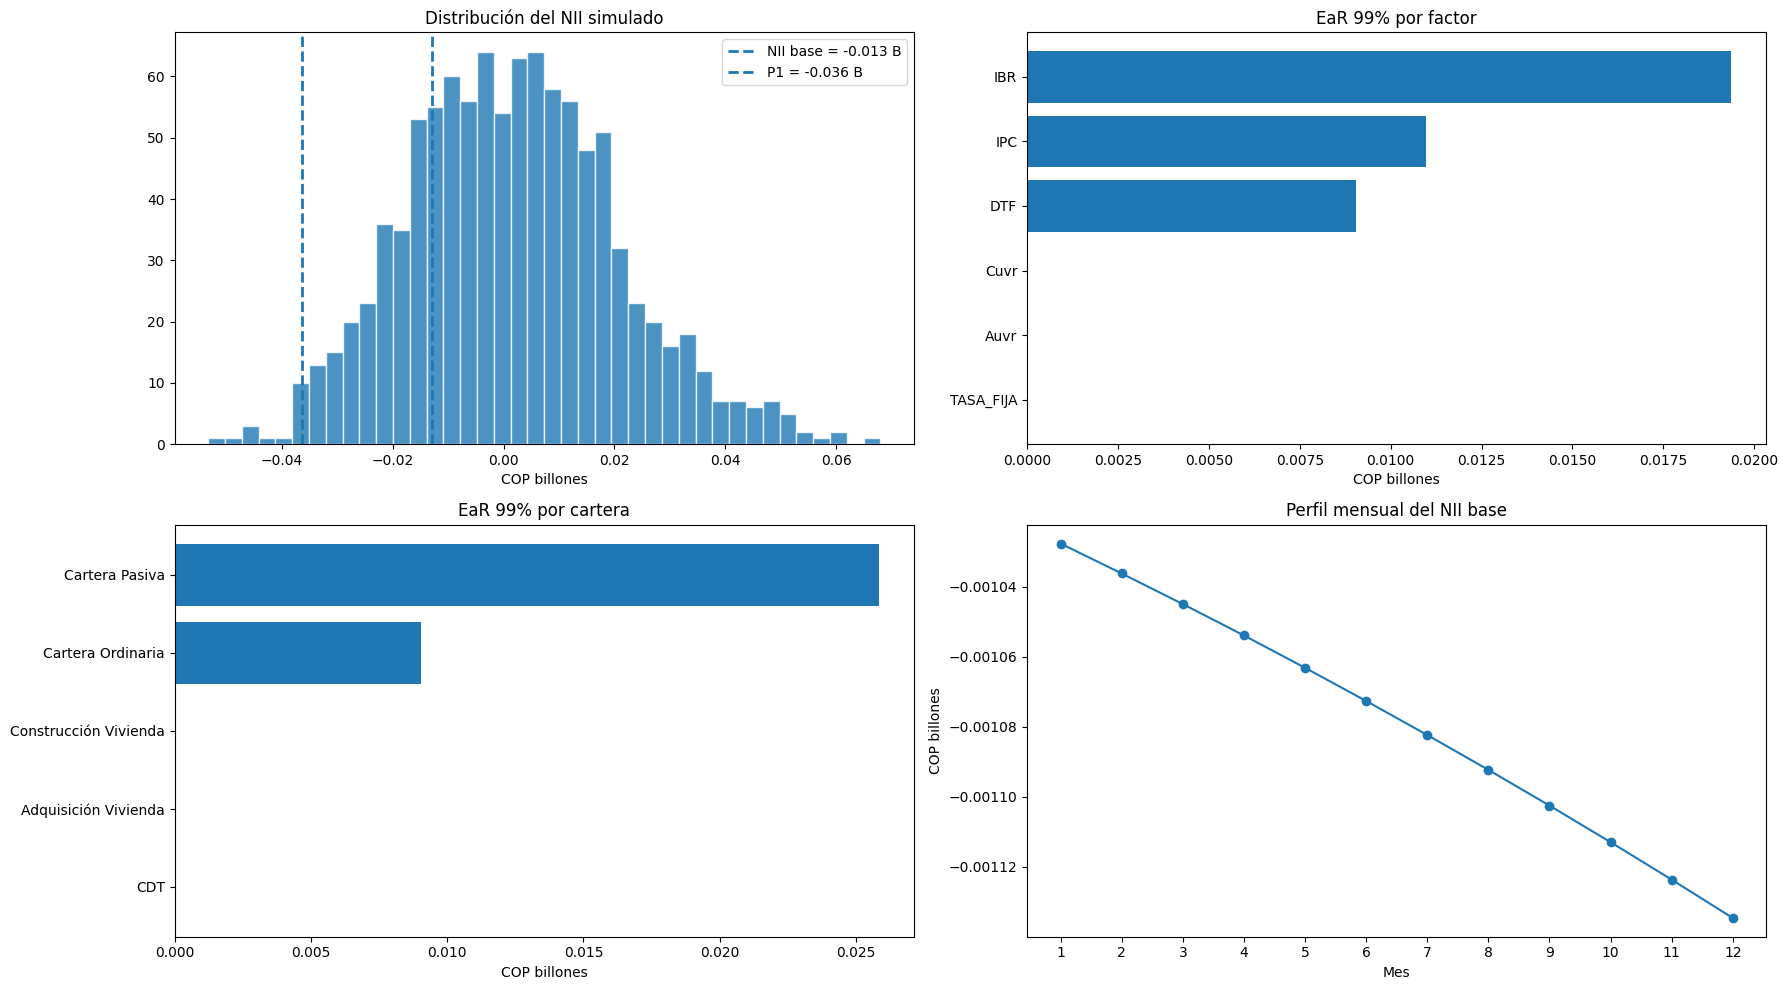


ARCHIVOS GENERADOS
Excel: /content/drive/MyDrive/Portafolio/Prueba_1/EaR_resultados_corregidos.xlsx
Gráfico: /content/drive/MyDrive/Portafolio/Prueba_1/ear_resumen.png

Script finalizado.


In [16]:

# ============================================================
# EARNINGS AT RISK (EaR) - BANCOLOMBIA
# Script listo para Google Colab
# ============================================================
# Enfoque:
#   - NII sobre base devengada (accrual), no caja
#   - Horizonte: 12 meses
#   - Escenarios: parquet con trayectorias mensuales por escenario
#   - Resultados: total, por factor y por cartera
#
# Supuestos explícitos principales:
# 1) El NII se reconoce mensualmente por devengo.
# 2) Para tasas variables, el indicador base es la trayectoria simulada
#    mensual del escenario.
# 3) El spread se suma/resta al indicador. En DTF se suma/resta primero
#    a la tasa trimestral anticipada y luego se convierte a EA.
# 4) PeriodoInteres/FrecuenciaInteres se usa como frecuencia de repricing
#    (reset). La tasa queda fija dentro de cada bloque de reset.
# 5) Para CREG se usa amortización mensual tipo francés con la tasa efectiva
#    mensual vigente en cada mes. Esto aproxima el NII regulatorio sobre
#    base devengada y evita mezclar NII con calendario de caja.
# 6) DSCTO e INTPER no amortizan capital hasta vencimiento.
# 7) Las posiciones que inician después de la fecha de corte se incluyen
#    desde su fecha de inicio y el primer/último mes se prorratean por días.
# 8) Signo del NII: naturaleza A = + ; naturaleza P = -.
#    Se respetan dos excepciones observadas en el archivo:
#    015ZZUU y 020CCFF deben tratarse como pasivos.
# ============================================================

from google.colab import drive
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings("ignore")

# =========================
# 0. PARÁMETROS
# =========================
drive.mount('/content/drive')

RUTA_BALANCE = '/content/drive/MyDrive/Portafolio/Prueba_1/data/Balance.xlsx'
RUTA_FACTORES = '/content/drive/MyDrive/Portafolio/Prueba_1/data/Factores de Riesgo.xlsx'
RUTA_SIM = '/content/drive/MyDrive/Portafolio/Prueba_1/data/simulacion_VAR_bootstrap/escenarios_VAR_bootstrap_long.parquet'
RUTA_SALIDA = '/content/drive/MyDrive/Portafolio/Prueba_1'

FECHA_CORTE = pd.Timestamp('2020-04-26')
N_MESES = 12
CONFIANZA = 0.99

FACTOR_COLS = ['DTF', 'IBR', 'IPC', 'Cuvr', 'Auvr', 'TA_Jur']
DIFF_COLS = [f'diff_{x}' for x in FACTOR_COLS]

# =========================
# 1. CARGA Y LIMPIEZA
# =========================
balance = pd.read_excel(RUTA_BALANCE)
factores = pd.read_excel(RUTA_FACTORES)
escenarios = pd.read_parquet(RUTA_SIM)

# Normalización columnas
balance.columns = [c.strip() for c in balance.columns]
factores.columns = [c.strip() for c in factores.columns]
escenarios.columns = [c.strip() for c in escenarios.columns]

# Fechas
balance['Fecha Inicio'] = pd.to_datetime(balance['Fecha Inicio'], errors='coerce')
balance['Fecha Vencimiento'] = pd.to_datetime(balance['Fecha Vencimiento'], errors='coerce')
factores['Fecha'] = pd.to_datetime(factores['Fecha'], errors='coerce')
escenarios['fecha_futura'] = pd.to_datetime(escenarios['fecha_futura'], errors='coerce')

# Strings
for col in ['PeriodoInteres', 'PlanAmortizacion', 'Tasa', 'naturaleza', 'Cartera', 'Signo', 'Código']:
    balance[col] = balance[col].astype(str).str.strip()

# SaldoCapital robusto
balance['SaldoCapital'] = (
    balance['SaldoCapital']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.strip()
    .replace('', np.nan)
    .astype(float)
)

# Frecuencia robusta
balance['FrecuenciaInteres'] = pd.to_numeric(balance['FrecuenciaInteres'], errors='coerce')

# Filtrar posiciones relevantes para el horizonte:
#   - que no hayan vencido al corte
#   - que puedan estar activas dentro del año siguiente
FECHA_FIN = FECHA_CORTE + pd.DateOffset(months=N_MESES)

balance = balance[
    (balance['Fecha Inicio'] <= FECHA_CORTE) &
    (balance['Fecha Vencimiento'] > FECHA_CORTE)
].copy().reset_index(drop=True)

# Ordenar escenarios
escenarios = escenarios.sort_values(['escenario', 'horizonte']).reset_index(drop=True)

print("="*90)
print("BALANCE - columnas")
print(balance.columns.tolist())
print("\nFACTORES - columnas")
print(factores.columns.tolist())
print("\nESCENARIOS - columnas")
print(escenarios.columns.tolist())
print("="*90)

# Validaciones mínimas
assert all(col in escenarios.columns for col in ['escenario', 'horizonte', 'fecha_futura'] + FACTOR_COLS), \
    "El parquet no tiene la estructura esperada."
assert factores['Fecha'].notna().any(), "No se pudo leer la fecha del histórico."
assert len(balance) > 0, "No quedaron posiciones activas después del filtro."

# Confirmar estructura del parquet
check_h = escenarios.groupby('escenario')['horizonte'].nunique().value_counts().to_dict()
check_n = escenarios.groupby('escenario').size().value_counts().to_dict()
print("Horizontes únicos por escenario:", check_h)
print("Número de filas por escenario:", check_n)

# =========================
# 2. UTILIDADES
# =========================
def obtener_signo_posicion(row):
    signo = 1.0 if row['naturaleza'] == 'A' else -1.0
    if row['Código'] in ['015ZZUU', '020CCFF']:
        signo = -1.0
    return signo

def frecuencia_reset_meses(row):
    """
    Interpreta la frecuencia de repricing/reset.
    Si FrecuenciaInteres > 1 se asume en días.
    En caso contrario usa PeriodoInteres.
    """
    freq = row['FrecuenciaInteres']
    periodo = row['PeriodoInteres']

    if pd.notna(freq) and freq > 1:
        return max(1, int(round(freq / 30.0)))  # 90 dias ~ 3 meses

    mapa = {'M': 1, 'T': 3, 'S': 6, 'D': 12, 'A': 12}
    return mapa.get(periodo, 1)

def tasa_ea_aplicable(factor, indicador_decimal, spread_pct, signo_spread):
    """
    Retorna tasa efectiva anual en decimal.
    - factor: DTF, IBR, IPC, Cuvr, Auvr, TA_Jur
    - indicador_decimal: valor simulado del factor en decimal
    - spread_pct: spread en puntos porcentuales
    """
    sp = (0.0 if pd.isna(spread_pct) else float(spread_pct)) / 100.0
    sgn = 1.0 if str(signo_spread).strip() == '+' else -1.0

    if factor == 'DTF':
        # La instrucción de la prueba dice:
        # "el spread debe sumarse al indicador. En el caso de la DTF
        # súmelo a la tasa trimestral anticipada".
        ta = indicador_decimal + sgn * sp
        ta = min(max(ta, -0.95), 0.95)  # protección numérica
        # TA trimestral anticipada -> EA
        ea = (1.0 + (ta / (1.0 - ta)) / 4.0) ** 4 - 1.0
        return ea

    else:
        ea = indicador_decimal + sgn * sp
        return ea

def cuota_francesa(saldo, tasa_m, n):
    if n <= 0:
        return 0.0
    if abs(tasa_m) < 1e-12:
        return saldo / n
    return saldo * tasa_m / (1.0 - (1.0 + tasa_m) ** (-n))

def meses_restantes(fecha_ref, fecha_vto):
    return max(1, (fecha_vto.year - fecha_ref.year) * 12 + (fecha_vto.month - fecha_ref.month))

def construir_meses_proyeccion(trayectoria):
    """
    Crea buckets mensuales [inicio_mes, fin_mes] a partir del parquet.
    Mes 1: desde FECHA_CORTE hasta fecha_futura(1)
    Mes k>1: desde fecha_futura(k-1) hasta fecha_futura(k)
    """
    filas = []
    prev = FECHA_CORTE
    for _, r in trayectoria.sort_values('horizonte').iterrows():
        fin = pd.Timestamp(r['fecha_futura'])
        filas.append({
            'horizonte': int(r['horizonte']),
            'inicio_bucket': prev,
            'fin_bucket': fin
        })
        prev = fin
    return pd.DataFrame(filas)

def fraccion_activa_mes(fecha_ini_pos, fecha_vto_pos, inicio_bucket, fin_bucket):
    """
    Proporción de días activos de la posición dentro del bucket mensual.
    Usa superposición de intervalos (inicio_bucket, fin_bucket].
    """
    ini = max(pd.Timestamp(fecha_ini_pos), pd.Timestamp(inicio_bucket))
    fin = min(pd.Timestamp(fecha_vto_pos), pd.Timestamp(fin_bucket))
    dias_bucket = max(1, (pd.Timestamp(fin_bucket) - pd.Timestamp(inicio_bucket)).days)
    dias_activos = max(0, (fin - ini).days)
    return dias_activos / dias_bucket

def tasa_ea_mes(row, trayectoria, mes_idx):
    """
    Devuelve la TEA aplicable en el mes mes_idx (1..12).
    Para variable: se resetea por bloques según frecuencia.
    """
    factor = row['Tasa']
    if factor == 'TASA_FIJA':
        return float(row['TasaBase']) / 100.0

    q = frecuencia_reset_meses(row)
    mes_reset = ((mes_idx - 1) // q) * q + 1  # 1,1,1,4,4,4,...
    fila = trayectoria.loc[trayectoria['horizonte'] == mes_reset].iloc[0]
    indicador = float(fila[factor])
    return tasa_ea_aplicable(
        factor=factor,
        indicador_decimal=indicador,
        spread_pct=row['PuntosAdicionales'],
        signo_spread=row['Signo']
    )

def calcular_nii_posicion(row, trayectoria, buckets):
    """
    NII anual de una posición bajo una trayectoria de 12 meses.
    Enfoque sobre base devengada mensual.
    """
    saldo = float(row['SaldoCapital'])
    fecha_ini = pd.Timestamp(row['Fecha Inicio'])
    fecha_vto = pd.Timestamp(row['Fecha Vencimiento'])
    plan = row['PlanAmortizacion']
    signo = obtener_signo_posicion(row)

    nii_total = 0.0
    nii_mensual = []

    for mes in range(1, N_MESES + 1):
        bucket = buckets.loc[buckets['horizonte'] == mes].iloc[0]
        inicio_b = bucket['inicio_bucket']
        fin_b = bucket['fin_bucket']

        # si la posición aún no ha iniciado o ya venció, no aporta
        frac = fraccion_activa_mes(fecha_ini, fecha_vto, inicio_b, fin_b)
        if frac <= 0 or saldo <= 0:
            nii_mensual.append(0.0)
            continue

        tea = tasa_ea_mes(row, trayectoria, mes)
        tasa_m = (1.0 + tea) ** (1.0 / 12.0) - 1.0

        interes_mes = saldo * tasa_m * frac
        nii_mes = signo * interes_mes
        nii_total += nii_mes
        nii_mensual.append(nii_mes)

        # Evolución del saldo
        if plan == 'CREG':
            n_rest = meses_restantes(pd.Timestamp(fin_b), fecha_vto)
            cuota = cuota_francesa(saldo, tasa_m, n_rest)
            amort = max(0.0, cuota - saldo * tasa_m)
            amort = min(amort, saldo)
            saldo -= amort

        elif plan in ['INTPER', 'DSCTO']:
            if pd.Timestamp(fin_b) >= fecha_vto:
                saldo = 0.0

        else:
            # Por seguridad: si aparece otro plan, no amortiza
            if pd.Timestamp(fin_b) >= fecha_vto:
                saldo = 0.0

    return nii_total, np.array(nii_mensual)

def valorar_portafolio(balance_df, trayectoria):
    """
    Devuelve:
      - total NII
      - detalle por posición
      - NII mensual total (12,)
      - agregados por factor
      - agregados por cartera
    """
    buckets = construir_meses_proyeccion(trayectoria)

    total = 0.0
    nii_mensual_total = np.zeros(N_MESES)
    detalle = []
    agg_factor = {}
    agg_cartera = {}

    for _, row in balance_df.iterrows():
        nii_pos, nii_mensual_pos = calcular_nii_posicion(row, trayectoria, buckets)
        total += nii_pos
        nii_mensual_total += nii_mensual_pos

        fac = row['Tasa']
        car = row['Cartera']
        agg_factor[fac] = agg_factor.get(fac, 0.0) + nii_pos
        agg_cartera[car] = agg_cartera.get(car, 0.0) + nii_pos

        detalle.append({
            'Código': row['Código'],
            'Cartera': row['Cartera'],
            'Factor': row['Tasa'],
            'PlanAmortizacion': row['PlanAmortizacion'],
            'Naturaleza': row['naturaleza'],
            'SaldoCapital': row['SaldoCapital'],
            'NII': nii_pos
        })

    return total, pd.DataFrame(detalle), nii_mensual_total, agg_factor, agg_cartera

# =========================
# 3. TRAYECTORIA BASE
# =========================
factores = factores.sort_values('Fecha').reset_index(drop=True)
tasas_base = factores.loc[factores['Fecha'] <= FECHA_CORTE].iloc[-1]

trayectoria_base = pd.DataFrame({
    'horizonte': np.arange(1, N_MESES + 1),
    'fecha_futura': [FECHA_CORTE + pd.offsets.MonthEnd(i) for i in range(1, N_MESES + 1)],
    'DTF': tasas_base['DTF'],
    'IBR': tasas_base['IBR'],
    'IPC': tasas_base['IPC'],
    'Cuvr': tasas_base['Cuvr'],
    'Auvr': tasas_base['Auvr'],
    'TA_Jur': tasas_base['TA_Jur']
})

nii_base, detalle_base, nii_mensual_base, base_factor, base_cartera = valorar_portafolio(balance, trayectoria_base)

print("\n" + "="*90)
print("NII BASE")
print("="*90)
print(f"NII base total: {nii_base:,.2f}")

# =========================
# 4. DICCIONARIO DE ESCENARIOS
# =========================
escenarios_dict = {
    esc: df[['horizonte', 'fecha_futura'] + FACTOR_COLS].copy().reset_index(drop=True)
    for esc, df in escenarios.groupby('escenario')
}

N_SIM = len(escenarios_dict)
print(f"Escenarios detectados: {N_SIM}")

# =========================
# 5. SIMULACIÓN PORTAFOLIO
# =========================
res_total = []
res_factor = []
res_cartera = []
res_mensual = []

for i, (esc, tray) in enumerate(escenarios_dict.items(), start=1):
    nii_total, _, nii_mensual, agg_factor, agg_cartera = valorar_portafolio(balance, tray)

    res_total.append({'escenario': esc, 'NII': nii_total})
    res_mensual.append({'escenario': esc, **{f'NII_mes_{m}': nii_mensual[m-1] for m in range(1, N_MESES + 1)}})

    fila_factor = {'escenario': esc}
    for k in sorted(balance['Tasa'].unique()):
        fila_factor[k] = agg_factor.get(k, 0.0)
    res_factor.append(fila_factor)

    fila_cartera = {'escenario': esc}
    for k in sorted(balance['Cartera'].unique()):
        fila_cartera[k] = agg_cartera.get(k, 0.0)
    res_cartera.append(fila_cartera)

    if i % 100 == 0 or i == 1 or i == N_SIM:
        print(f"Valorados {i:>4} / {N_SIM} escenarios")

df_total = pd.DataFrame(res_total).sort_values('escenario').reset_index(drop=True)
df_factor_sims = pd.DataFrame(res_factor).sort_values('escenario').reset_index(drop=True)
df_cartera_sims = pd.DataFrame(res_cartera).sort_values('escenario').reset_index(drop=True)
df_mensual_sims = pd.DataFrame(res_mensual).sort_values('escenario').reset_index(drop=True)

# =========================
# 6. EAR TOTAL
# =========================
p1_total = np.percentile(df_total['NII'], 1)
p5_total = np.percentile(df_total['NII'], 5)
ear_99 = nii_base - p1_total
ear_95 = nii_base - p5_total

resumen_total = pd.DataFrame({
    'Métrica': [
        'NII base',
        'Media NII simulado',
        'Mediana NII simulado',
        'Percentil 1% NII',
        'Percentil 5% NII',
        'EaR 99%',
        'EaR 95%',
        'Número de simulaciones',
        'Fecha de corte',
        'Horizonte (meses)'
    ],
    'Valor': [
        nii_base,
        df_total['NII'].mean(),
        df_total['NII'].median(),
        p1_total,
        p5_total,
        ear_99,
        ear_95,
        N_SIM,
        str(FECHA_CORTE.date()),
        N_MESES
    ]
})

print("\n" + "="*90)
print("RESULTADO TOTAL")
print("="*90)
print(resumen_total.to_string(index=False))

# =========================
# 7. EAR POR FACTOR Y POR CARTERA
# =========================
rows_factor = []
for fac in sorted(balance['Tasa'].unique()):
    base_val = base_factor.get(fac, 0.0)
    p1 = np.percentile(df_factor_sims[fac], 1)
    p5 = np.percentile(df_factor_sims[fac], 5)
    rows_factor.append({
        'Factor': fac,
        'NII base': base_val,
        'Media': df_factor_sims[fac].mean(),
        'Mediana': df_factor_sims[fac].median(),
        'Percentil 1%': p1,
        'Percentil 5%': p5,
        'EaR 99%': base_val - p1,
        'EaR 95%': base_val - p5
    })
df_ear_factor = pd.DataFrame(rows_factor).sort_values('EaR 99%', ascending=False).reset_index(drop=True)

rows_cartera = []
for car in sorted(balance['Cartera'].unique()):
    base_val = base_cartera.get(car, 0.0)
    p1 = np.percentile(df_cartera_sims[car], 1)
    p5 = np.percentile(df_cartera_sims[car], 5)
    rows_cartera.append({
        'Cartera': car,
        'NII base': base_val,
        'Media': df_cartera_sims[car].mean(),
        'Mediana': df_cartera_sims[car].median(),
        'Percentil 1%': p1,
        'Percentil 5%': p5,
        'EaR 99%': base_val - p1,
        'EaR 95%': base_val - p5
    })
df_ear_cartera = pd.DataFrame(rows_cartera).sort_values('EaR 99%', ascending=False).reset_index(drop=True)

print("\n" + "="*90)
print("EaR POR FACTOR")
print("="*90)
print(df_ear_factor.to_string(index=False))

print("\n" + "="*90)
print("EaR POR CARTERA")
print("="*90)
print(df_ear_cartera.to_string(index=False))

# =========================
# 8. VISUALES
# =========================
B = 1e9  # billones COP

fig = plt.figure(figsize=(18, 10))
ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

# Distribución NII
ax1.hist(df_total['NII'] / B, bins=40, edgecolor='white', alpha=0.8)
ax1.axvline(nii_base / B, linestyle='--', linewidth=2, label=f'NII base = {nii_base/B:,.3f} B')
ax1.axvline(p1_total / B, linestyle='--', linewidth=2, label=f'P1 = {p1_total/B:,.3f} B')
ax1.set_title('Distribución del NII simulado')
ax1.set_xlabel('COP billones')
ax1.legend()

# EaR por factor
tmp = df_ear_factor.sort_values('EaR 99%')
ax2.barh(tmp['Factor'], tmp['EaR 99%'] / B)
ax2.set_title('EaR 99% por factor')
ax2.set_xlabel('COP billones')

# EaR por cartera
tmp2 = df_ear_cartera.sort_values('EaR 99%')
ax3.barh(tmp2['Cartera'], tmp2['EaR 99%'] / B)
ax3.set_title('EaR 99% por cartera')
ax3.set_xlabel('COP billones')

# NII mensual base
ax4.plot(range(1, N_MESES + 1), nii_mensual_base / B, marker='o')
ax4.set_title('Perfil mensual del NII base')
ax4.set_xlabel('Mes')
ax4.set_ylabel('COP billones')
ax4.set_xticks(range(1, N_MESES + 1))

plt.tight_layout()
RUTA_GRAFICO = f'{RUTA_SALIDA}/ear_resumen.png'
plt.savefig(RUTA_GRAFICO, dpi=160, bbox_inches='tight')
plt.show()

# =========================
# 9. EXPORTAR A EXCEL
# =========================
RUTA_XLSX = f'{RUTA_SALIDA}/EaR_resultados_corregidos.xlsx'

detalle_base = detalle_base.sort_values('NII', ascending=False).reset_index(drop=True)
df_nii_mensual_base = pd.DataFrame({
    'Mes': list(range(1, N_MESES + 1)),
    'NII_mensual_base': nii_mensual_base
})

with pd.ExcelWriter(RUTA_XLSX, engine='openpyxl') as writer:
    resumen_total.to_excel(writer, sheet_name='Resumen_total', index=False)
    df_ear_factor.to_excel(writer, sheet_name='EaR_por_factor', index=False)
    df_ear_cartera.to_excel(writer, sheet_name='EaR_por_cartera', index=False)
    detalle_base.to_excel(writer, sheet_name='Detalle_base', index=False)
    df_total.to_excel(writer, sheet_name='NII_sim_total', index=False)
    df_factor_sims.to_excel(writer, sheet_name='NII_sim_factor', index=False)
    df_cartera_sims.to_excel(writer, sheet_name='NII_sim_cartera', index=False)
    df_mensual_sims.to_excel(writer, sheet_name='NII_sim_mensual', index=False)
    df_nii_mensual_base.to_excel(writer, sheet_name='NII_base_mensual', index=False)

print("\n" + "="*90)
print("ARCHIVOS GENERADOS")
print("="*90)
print("Excel:", RUTA_XLSX)
print("Gráfico:", RUTA_GRAFICO)
print("\nScript finalizado.")


In [17]:
# Posiciones que empiezan después de la fecha de corte
pos_despues_corte = balance[balance['Fecha Inicio'] > FECHA_CORTE].copy()

print("Cantidad de posiciones que aparecen después del corte:", len(pos_despues_corte))

# Si quieres ver cuáles son
print(
    pos_despues_corte[
        ['Código', 'Cartera', 'naturaleza', 'Fecha Inicio', 'Fecha Vencimiento', 'SaldoCapital']
    ].sort_values('Fecha Inicio')
)

Cantidad de posiciones que aparecen después del corte: 0
Empty DataFrame
Columns: [Código, Cartera, naturaleza, Fecha Inicio, Fecha Vencimiento, SaldoCapital]
Index: []


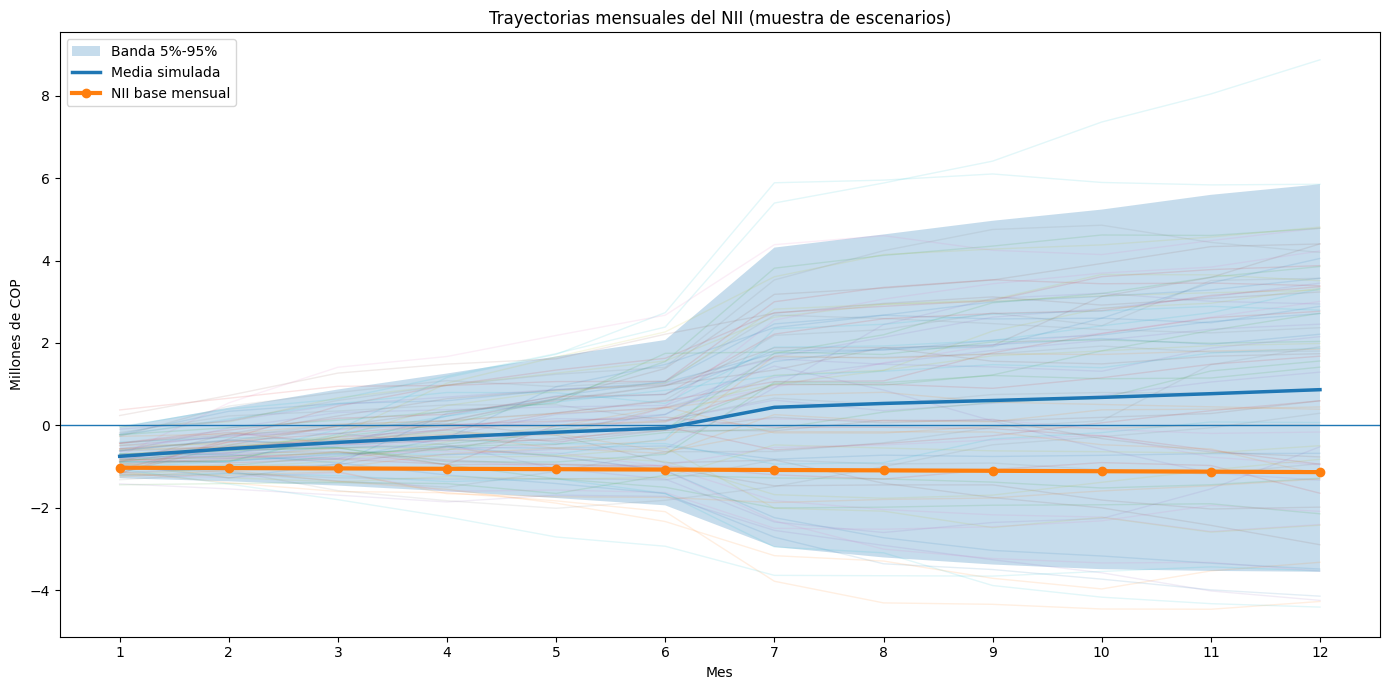

In [18]:
import numpy as np
import matplotlib.pyplot as plt

cols_nii = [f'NII_mes_{m}' for m in range(1, 13)]
trayectorias = df_mensual_sims[cols_nii].copy()

UNIDAD = 1e6
NOMBRE_UNIDAD = 'Millones de COP'

trayectorias_plot = trayectorias / UNIDAD
nii_base_plot = nii_mensual_base / UNIDAD

media = trayectorias_plot.mean(axis=0).values
p5 = trayectorias_plot.quantile(0.05, axis=0).values
p95 = trayectorias_plot.quantile(0.95, axis=0).values

meses = np.arange(1, 13)

# Tomar una muestra de trayectorias
n_mostrar = 80
muestra = trayectorias_plot.sample(n=min(n_mostrar, len(trayectorias_plot)), random_state=42)

plt.figure(figsize=(14, 7))

for _, fila in muestra.iterrows():
    plt.plot(meses, fila.values, alpha=0.12, linewidth=1)

plt.fill_between(meses, p5, p95, alpha=0.25, label='Banda 5%-95%')
plt.plot(meses, media, linewidth=2.5, label='Media simulada')
plt.plot(meses, nii_base_plot, linewidth=3, marker='o', label='NII base mensual')

plt.axhline(0, linewidth=1)
plt.title('Trayectorias mensuales del NII (muestra de escenarios)')
plt.xlabel('Mes')
plt.ylabel(NOMBRE_UNIDAD)
plt.xticks(meses)
plt.legend()
plt.tight_layout()
plt.show()

revision men 6 y 7

In [19]:
import pandas as pd
import numpy as np

# ============================================================
# 1. CAMBIO TOTAL ENTRE MES 6 Y MES 7
# ============================================================
cols_nii = [f'NII_mes_{m}' for m in range(1, 13)]

resumen_salto = pd.DataFrame({
    'escenario': df_mensual_sims['escenario'],
    'NII_mes_6': df_mensual_sims['NII_mes_6'],
    'NII_mes_7': df_mensual_sims['NII_mes_7'],
})
resumen_salto['delta_7_6'] = resumen_salto['NII_mes_7'] - resumen_salto['NII_mes_6']

print("="*90)
print("SALTO TOTAL ENTRE MES 6 Y MES 7")
print("="*90)
print(resumen_salto['delta_7_6'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))

# Escenarios con mayor salto positivo y negativo
print("\nTop 10 saltos positivos:")
print(resumen_salto.sort_values('delta_7_6', ascending=False).head(10))

print("\nTop 10 saltos negativos:")
print(resumen_salto.sort_values('delta_7_6', ascending=True).head(10))

SALTO TOTAL ENTRE MES 6 Y MES 7
count    1.000000e+03
mean     5.023094e+05
std      1.201585e+06
min     -2.829719e+06
1%      -2.005823e+06
5%      -1.339681e+06
25%     -3.357418e+05
50%      4.188678e+05
75%      1.255827e+06
95%      2.540074e+06
99%      3.446422e+06
max      4.723743e+06
Name: delta_7_6, dtype: float64

Top 10 saltos positivos:
     escenario     NII_mes_6     NII_mes_7     delta_7_6
598        599  9.049428e+05  5.628686e+06  4.723743e+06
492        493  2.819531e+06  7.486410e+06  4.666879e+06
618        619  1.695504e+06  6.227161e+06  4.531657e+06
752        753  2.084517e+06  6.340557e+06  4.256040e+06
166        167  1.025238e+06  5.091240e+06  4.066002e+06
232        233  1.578132e+06  5.629344e+06  4.051212e+06
60          61  2.266242e+06  6.288444e+06  4.022202e+06
445        446  2.523366e+06  6.417427e+06  3.894060e+06
92          93  2.308980e+06  5.879429e+06  3.570449e+06
805        806  1.163003e+06  4.621824e+06  3.458821e+06

Top 10 saltos nega

In [20]:
# ============================================================
# 2. CAMBIO ENTRE MES 6 Y MES 7 POR CARTERA
# ============================================================
# Esto recalcula por escenario el NII mensual por cartera
# usando tu función valorar_portafolio(balance, trayectoria)

carteras = sorted(balance['Cartera'].unique())
rows_cartera_m6m7 = []

for esc, tray in escenarios_dict.items():
    buckets = construir_meses_proyeccion(tray)

    # acumuladores por cartera
    cartera_mes_6 = {c: 0.0 for c in carteras}
    cartera_mes_7 = {c: 0.0 for c in carteras}

    for _, row in balance.iterrows():
        _, nii_mensual_pos = calcular_nii_posicion(row, tray, buckets)
        cartera = row['Cartera']
        cartera_mes_6[cartera] += nii_mensual_pos[5]   # mes 6
        cartera_mes_7[cartera] += nii_mensual_pos[6]   # mes 7

    fila = {'escenario': esc}
    for c in carteras:
        fila[f'{c}_mes6'] = cartera_mes_6[c]
        fila[f'{c}_mes7'] = cartera_mes_7[c]
        fila[f'{c}_delta_7_6'] = cartera_mes_7[c] - cartera_mes_6[c]
    rows_cartera_m6m7.append(fila)

df_cartera_m6m7 = pd.DataFrame(rows_cartera_m6m7).sort_values('escenario').reset_index(drop=True)

print("="*90)
print("CAMBIO PROMEDIO ENTRE MES 6 Y MES 7 POR CARTERA")
print("="*90)

resumen_cartera_salto = []
for c in carteras:
    resumen_cartera_salto.append({
        'Cartera': c,
        'Media delta 7-6': df_cartera_m6m7[f'{c}_delta_7_6'].mean(),
        'Mediana delta 7-6': df_cartera_m6m7[f'{c}_delta_7_6'].median(),
        'P5 delta 7-6': df_cartera_m6m7[f'{c}_delta_7_6'].quantile(0.05),
        'P95 delta 7-6': df_cartera_m6m7[f'{c}_delta_7_6'].quantile(0.95),
    })

resumen_cartera_salto = pd.DataFrame(resumen_cartera_salto).sort_values('Media delta 7-6', ascending=False)
print(resumen_cartera_salto)

CAMBIO PROMEDIO ENTRE MES 6 Y MES 7 POR CARTERA
                 Cartera  Media delta 7-6  Mediana delta 7-6  P5 delta 7-6  \
3         Cartera Pasiva    592629.225885      514025.813095 -1.347789e+06   
1                    CDT         0.000000           0.000000  0.000000e+00   
4  Construcción Vivienda       -24.167440         -56.221733 -1.083484e+03   
0   Adquisición Vivienda     -2783.324317       -2777.991212 -3.357950e+03   
2      Cartera Ordinaria    -87512.327176      -85211.838704 -1.948060e+05   

   P95 delta 7-6  
3   2.706654e+06  
1   0.000000e+00  
4   1.173307e+03  
0  -2.225891e+03  
2   1.698710e+04  


In [21]:
# ============================================================
# 3. CAMBIO ENTRE MES 6 Y MES 7 POR FACTOR
# ============================================================
factores = sorted(balance['Tasa'].unique())
rows_factor_m6m7 = []

for esc, tray in escenarios_dict.items():
    buckets = construir_meses_proyeccion(tray)

    factor_mes_6 = {f: 0.0 for f in factores}
    factor_mes_7 = {f: 0.0 for f in factores}

    for _, row in balance.iterrows():
        _, nii_mensual_pos = calcular_nii_posicion(row, tray, buckets)
        factor = row['Tasa']
        factor_mes_6[factor] += nii_mensual_pos[5]   # mes 6
        factor_mes_7[factor] += nii_mensual_pos[6]   # mes 7

    fila = {'escenario': esc}
    for f in factores:
        fila[f'{f}_mes6'] = factor_mes_6[f]
        fila[f'{f}_mes7'] = factor_mes_7[f]
        fila[f'{f}_delta_7_6'] = factor_mes_7[f] - factor_mes_6[f]
    rows_factor_m6m7.append(fila)

df_factor_m6m7 = pd.DataFrame(rows_factor_m6m7).sort_values('escenario').reset_index(drop=True)

print("="*90)
print("CAMBIO PROMEDIO ENTRE MES 6 Y MES 7 POR FACTOR")
print("="*90)

resumen_factor_salto = []
for f in factores:
    resumen_factor_salto.append({
        'Factor': f,
        'Media delta 7-6': df_factor_m6m7[f'{f}_delta_7_6'].mean(),
        'Mediana delta 7-6': df_factor_m6m7[f'{f}_delta_7_6'].median(),
        'P5 delta 7-6': df_factor_m6m7[f'{f}_delta_7_6'].quantile(0.05),
        'P95 delta 7-6': df_factor_m6m7[f'{f}_delta_7_6'].quantile(0.95),
    })

resumen_factor_salto = pd.DataFrame(resumen_factor_salto).sort_values('Media delta 7-6', ascending=False)
print(resumen_factor_salto)

CAMBIO PROMEDIO ENTRE MES 6 Y MES 7 POR FACTOR
      Factor  Media delta 7-6  Mediana delta 7-6  P5 delta 7-6  P95 delta 7-6
4        IPC    457660.608455      408304.638544 -1.094624e+06   2.306079e+06
3        IBR    134968.617430      112387.536385 -4.001881e+05   7.449487e+05
1       Cuvr       -24.167440         -56.221733 -1.083484e+03   1.173307e+03
0       Auvr      -111.584700        -106.251594 -6.862102e+02   4.458488e+02
5  TASA_FIJA     -2671.739618       -2671.739618 -2.671740e+03  -2.671740e+03
2        DTF    -87512.327176      -85211.838704 -1.948060e+05   1.698710e+04


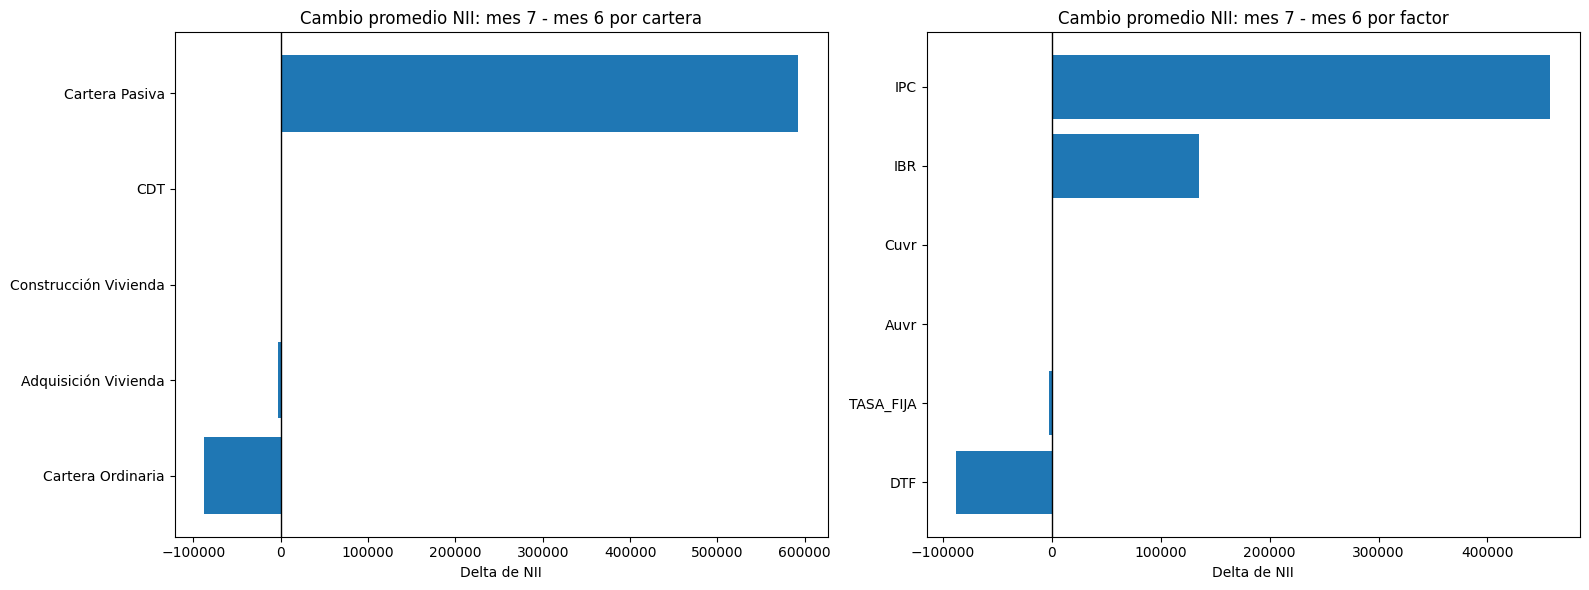

In [22]:
import matplotlib.pyplot as plt

# ============================================================
# 4. GRÁFICO DEL SALTO PROMEDIO POR CARTERA Y POR FACTOR
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

tmp1 = resumen_cartera_salto.sort_values('Media delta 7-6')
axes[0].barh(tmp1['Cartera'], tmp1['Media delta 7-6'])
axes[0].axvline(0, color='black', linewidth=1)
axes[0].set_title('Cambio promedio NII: mes 7 - mes 6 por cartera')
axes[0].set_xlabel('Delta de NII')

tmp2 = resumen_factor_salto.sort_values('Media delta 7-6')
axes[1].barh(tmp2['Factor'], tmp2['Media delta 7-6'])
axes[1].axvline(0, color='black', linewidth=1)
axes[1].set_title('Cambio promedio NII: mes 7 - mes 6 por factor')
axes[1].set_xlabel('Delta de NII')

plt.tight_layout()
plt.show()

Guardar en una carpeta los resultados

In [23]:
# ============================================================
# GUARDAR ARCHIVOS PARA STREAMLIT
# ============================================================
from pathlib import Path
import shutil

# Carpeta destino
RUTA_DESTINO = Path("/content/drive/MyDrive/Portafolio/Prueba_1/data_modelo_financiero")
RUTA_DESTINO.mkdir(parents=True, exist_ok=True)

print(f"Carpeta destino: {RUTA_DESTINO}")

# ------------------------------------------------------------
# 1. COPIAR INSUMOS ORIGINALES
# ------------------------------------------------------------
shutil.copy2(RUTA_BALANCE, RUTA_DESTINO / "Balance.xlsx")
shutil.copy2(RUTA_FACTORES, RUTA_DESTINO / "Factores de Riesgo.xlsx")
shutil.copy2(RUTA_SIM, RUTA_DESTINO / "escenarios_VAR_bootstrap_long.parquet")

# ------------------------------------------------------------
# 2. GUARDAR RESULTADOS
# ------------------------------------------------------------
resumen_total.to_csv(RUTA_DESTINO / "resumen_total.csv", index=False)
df_ear_factor.to_csv(RUTA_DESTINO / "ear_por_factor.csv", index=False)
df_ear_cartera.to_csv(RUTA_DESTINO / "ear_por_cartera.csv", index=False)
df_nii_mensual_base.to_csv(RUTA_DESTINO / "nii_base_mensual.csv", index=False)

df_total.to_parquet(RUTA_DESTINO / "nii_sim_total.parquet", index=False)
df_factor_sims.to_parquet(RUTA_DESTINO / "nii_sim_factor.parquet", index=False)
df_cartera_sims.to_parquet(RUTA_DESTINO / "nii_sim_cartera.parquet", index=False)
df_mensual_sims.to_parquet(RUTA_DESTINO / "nii_sim_mensual.parquet", index=False)
detalle_base.to_parquet(RUTA_DESTINO / "detalle_base.parquet", index=False)

# ------------------------------------------------------------
# 3. DICCIONARIO DE VARIABLES DEL BALANCE
# ------------------------------------------------------------
diccionario_variables_balance = pd.DataFrame({
    "Variable": [
        "Código", "PuntosAdicionales", "Signo", "TasaBase", "PeriodoInteres",
        "FrecuenciaInteres", "Fecha Inicio", "Fecha Vencimiento", "Cartera",
        "PlanAmortizacion", "SaldoCapital", "naturaleza", "Tasa"
    ],
    "Descripción": [
        "Identificador de la posición financiera.",
        "Spread o puntos adicionales sobre la tasa de referencia.",
        "Indica si el spread se suma o se resta a la tasa base.",
        "Tasa contractual cuando la posición está a tasa fija.",
        "Periodicidad contractual relevante para intereses o repricing (M, T, S, D, etc.).",
        "Frecuencia numérica asociada al esquema de interés o repricing.",
        "Fecha de inicio de la operación.",
        "Fecha de vencimiento de la operación.",
        "Cartera o segmento al que pertenece la posición.",
        "Esquema de amortización contractual.",
        "Saldo de capital sobre el cual se calculan los intereses.",
        "Naturaleza de la posición: A = activo, P = pasivo.",
        "Factor de riesgo o tipo de tasa asociado a la posición."
    ]
})

diccionario_variables_balance.to_csv(
    RUTA_DESTINO / "diccionario_variables_balance.csv",
    index=False
)

# ------------------------------------------------------------
# 4. VERIFICACIÓN FINAL
# ------------------------------------------------------------
archivos_guardados = sorted([p.name for p in RUTA_DESTINO.iterdir()])
print("\nArchivos guardados:")
for archivo in archivos_guardados:
    print("-", archivo)

Carpeta destino: /content/drive/MyDrive/Portafolio/Prueba_1/data_modelo_financiero

Archivos guardados:
- Balance.xlsx
- Factores de Riesgo.xlsx
- detalle_base.parquet
- diccionario_variables_balance.csv
- ear_por_cartera.csv
- ear_por_factor.csv
- escenarios_VAR_bootstrap_long.parquet
- nii_base_mensual.csv
- nii_sim_cartera.parquet
- nii_sim_factor.parquet
- nii_sim_mensual.parquet
- nii_sim_total.parquet
- resumen_total.csv
